<a href="https://colab.research.google.com/github/Humak1/catshackathon/blob/fat-cats/calculate_accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# I upload the zipped data folder (I need to do this every time the Colab session restarts)
import sys, os
if "google.colab" in sys.modules and not os.path.exists("carbon_intensity_data"):
    from google.colab import files
    files.upload()
    !unzip -q -o carbon_intensity_data.zip

In [7]:
def load_and_clean_data():
    # I read every CSV (one folder per region, one file per forecast run) into one table.
    # don't do this, keep regions separate

    # The file name tells me the postcode and when the forecast was made, e.g. WC1E_2026-05-12T00:00:00+00:00.csv
    frames = []
    for f in sorted(DATA_DIR.glob("*/*.csv")):
        df = pd.read_csv(f)
        df["region"] = f.parent.name
        _, df["forecast_issued"] = f.stem.split("_", 1)
        frames.append(df)

    raw = pd.concat(frames, ignore_index=True)
    # I turn the text dates into real UTC timestamps
    raw["datetime"] = pd.to_datetime(raw["datetime"], utc=True, format="ISO8601")
    raw["forecast_issued"] = pd.to_datetime(raw["forecast_issued"], utc=True, format="ISO8601")

    # drop early data, it was very incomplete
    raw = raw[raw.forecast_issued >= "2026-04-08"]

    # how many hours ahead is each forecast?
    raw["horizon_h"] = (raw["datetime"] - raw["forecast_issued"]).dt.total_seconds() / 3600

    return raw

In [8]:
def plot_timestep(data, timestamp):

    df = data[(data['datetime'] == timestamp)]

    fig, ax = plt.subplots(figsize=(10, 6))
    best = df

    # horrible way to get all the regions, lets refactor to index around them in the data structure
    regions = df.groupby("region").value.median().sort_values().index

    ax.boxplot([df.loc[df.region == r, "value"] for r in regions], vert=False, showfliers=False,
               tick_labels=[r.replace("_", " ") for r in regions])
    ax.set_xlabel("carbon intensity (gCO₂/kWh)")
    ax.set_title("Carbon intensity by region for one timestep")
    ax.grid()
    ax.set_xticks(np.linspace(0,399,20))
    plt.show()

    for region in regions:
        regional_data = df[df['region'] == region].value
        print(f"Region: {region} max: {regional_data.max()} min: {regional_data.min()} median: {regional_data.median()} lower quartile: {regional_data.quantile(0.25)} upper quartile: {regional_data.quantile(0.75)}")

In [9]:
data = load_and_clean_data()

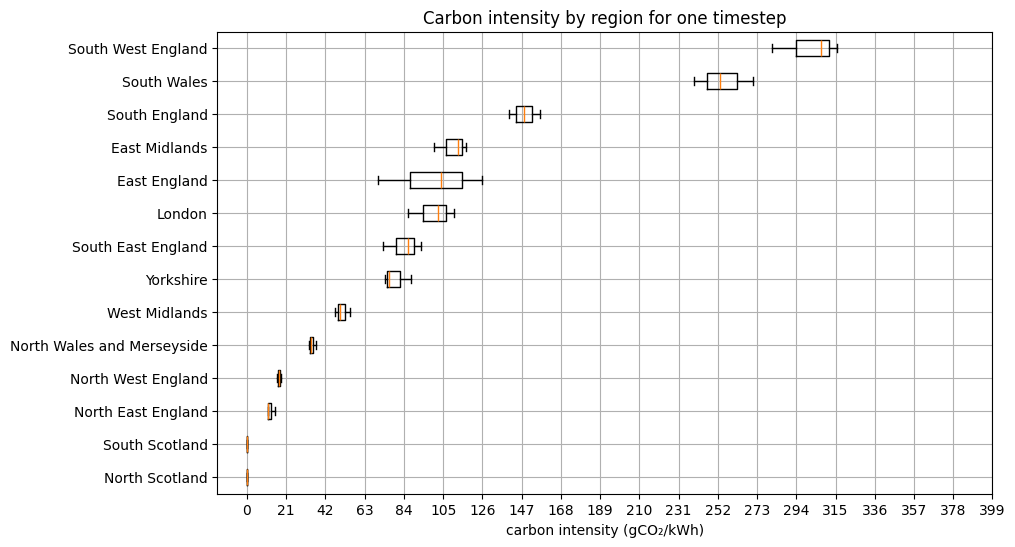

Region: North_Scotland max: 0 min: 0 median: 0.0 lower quartile: 0.0 upper quartile: 0.0
Region: South_Scotland max: 0 min: 0 median: 0.0 lower quartile: 0.0 upper quartile: 0.0
Region: North_East_England max: 15 min: 11 median: 11.0 lower quartile: 11.0 upper quartile: 13.0
Region: North_West_England max: 18 min: 16 median: 17.0 lower quartile: 16.5 upper quartile: 17.5
Region: North_Wales_and_Merseyside max: 37 min: 33 median: 34.0 lower quartile: 33.5 upper quartile: 35.5
Region: West_Midlands max: 55 min: 47 median: 50.0 lower quartile: 48.5 upper quartile: 52.5
Region: Yorkshire max: 88 min: 74 median: 76.0 lower quartile: 75.0 upper quartile: 82.0
Region: South_East_England max: 93 min: 73 median: 86.0 lower quartile: 79.5 upper quartile: 89.5
Region: London max: 111 min: 86 median: 102.0 lower quartile: 94.0 upper quartile: 106.5
Region: East_England max: 126 min: 70 median: 104.0 lower quartile: 87.0 upper quartile: 115.0
Region: East_Midlands max: 117 min: 100 median: 113.0 lo

In [10]:
plot_timestep(data, "2026-09-03 20:00:00")

In [11]:
# sanity checking
data[(data["datetime"] == "2026-09-02 20:00:00") & (data["region"] == "North_Scotland")]

,datetime,value,region,forecast_issued,horizon_h
313906,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-01 12:00:00+00:00,32.0
313990,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-01 18:00:00+00:00,26.0
314066,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-02 00:00:00+00:00,20.0
314130,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-02 06:00:00+00:00,14.0
314182,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-02 12:00:00+00:00,8.0


In [12]:
# for all (or most) datapoints we have 4 values for the same time from different forecasts
# each of these has a horizon_h which tells us its age
# we want to compare them
# use the one with the lowest horizon_h as the ground truth?
# plot abs difference of each value and ground_truth for all non-zero values of horizon_h